In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append('../')
from Scattering_Simulator import pairwise_method
from scipy import integrate
import matplotlib.cm as cm
from scipy.spatial.transform import Rotation as R
from gsd import hoomd
from scipy.interpolate import BSpline, splrep
from scipy.signal import savgol_filter
import os
import numpy as np
from scipy.spatial import cKDTree
import gsd.hoomd

In [39]:
import numpy as np
from scipy.spatial import cKDTree
import gsd.hoomd

def generate_fractal_aggregate(N, d, max_attempts=1000):
    positions = [np.array([0.0, 0.0, 0.0])]
    tree = cKDTree(positions)

    while len(positions) < N:
        success = False
        for _ in range(max_attempts):
            # Pick a random existing particle
            parent = positions[np.random.randint(len(positions))]

            # Generate a random direction
            direction = np.random.normal(size=3)
            direction /= np.linalg.norm(direction)

            # New candidate position ~1.2*d from the parent
            new_pos = parent + direction * d * 1.0

            # Only check that it’s close enough to the parent
            if np.min([np.linalg.norm(new_pos - p) for p in positions]) > d * 0.95:
                positions.append(new_pos)
                tree = cKDTree(positions)
                success = True
                break

        if not success:
            print(f"Max attempts reached, stopping at {len(positions)}")
            break

    return np.array(positions)


def generate_fcc_lattice(n_cells, lattice_constant):
    """
    Generate FCC lattice coordinates.

    Parameters:
    - n_cells: int
        Number of unit cells along each axis (creates n_cells^3 unit cells)
    - lattice_constant: float
        Distance between adjacent lattice points (unit cell edge length)

    Returns:
    - positions: np.ndarray, shape (N, 3)
        Cartesian coordinates of all particles in the FCC lattice
    """
    # FCC basis vectors (relative to unit cell corner)
    basis = np.array([
        [0.0, 0.0, 0.0],
        [0.5, 0.5, 0.0],
        [0.5, 0.0, 0.5],
        [0.0, 0.5, 0.5]
    ])
    
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * lattice_constant
                for b in basis:
                    pos = cell_origin + b * lattice_constant
                    positions.append(pos)
    
    return np.array(positions)


def save_xyz(filename, positions, particle_type='A'):
    with open(filename, 'w') as f:
        f.write(f"{len(positions)}\n")
        f.write("Generated by Python\n")
        for pos in positions:
            f.write(f"{particle_type} {pos[0]} {pos[1]} {pos[2]}\n")


In [206]:
positions = generate_fractal_aggregate(N=2000, d=26)
#positions = generate_fcc_lattice(10, 26)

In [13]:
save_xyz('../Data/HOOMD/fractal_aggregates_2000.xyz', positions)

## HOOMD-blue to SAXS
The purpose of this notebook is to convert HOOMD-blue simulations into SAXS curves that are directly comparble to SAXS data obtained experimentally. This is done first by extracting the positions and orientations of objects from the HOOMD-blue simulation file (.gsd file) and creating a model of the object being simulated (e.g., spheres, cubes). Then this information is used with the MC-DFM to simulate the scattering curve at any frame of the simulation. The following section is used to read the .gsd file and extract the positions and orientations. 

In [207]:
lattice_coordinates = positions

In [208]:
lattice_coordinates[0:6, :]

array([[  0.        ,   0.        ,   0.        ],
       [ -7.2665949 , -20.43247204, -14.34261778],
       [ -6.07056723,  21.51986609,  13.26814143],
       [-20.5575547 , -26.86973898,   7.05626027],
       [  7.29676748,   0.1775316 , -24.95447188],
       [ -1.1033483 ,  21.5694651 , -14.4755241 ]])

## Building Block 
The building block is defined as the object being simulated such as a sphere or cube. This is not saved in the .gsd file so we need to create this object here. 

In [209]:
def grid_points_in_sphere(D, spacing):
    """
    Generate a regular 3D grid of points spaced by 'spacing' that fit inside a sphere.

    Parameters
    ----------
    D : float
        Diameter of the sphere.
    spacing : float
        Distance between adjacent grid points.

    Returns
    -------
    points : np.ndarray of shape (M, 3)
        Grid points inside the sphere.
    """
    radius = D / 2.0
    r2 = radius ** 2

    # Create a 3D grid
    coords = np.arange(-radius, radius + spacing, spacing)
    X, Y, Z = np.meshgrid(coords, coords, coords)
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    # Keep only the points inside the sphere
    mask = np.sum(grid**2, axis=1) <= r2
    points = grid[mask]

    return points

def fill_cube_with_points(N, edge_length):
    """
    Fill a cube with N points approximately uniformly distributed.

    Parameters
    ----------
    N : int
        Number of points to place inside the cube.
    edge_length : float
        Length of each edge of the cube.

    Returns
    -------
    points : np.ndarray of shape (N, 3)
        Coordinates of the points inside the cube.
    """
    # Estimate number of points per side of the grid
    n_side = int(np.ceil(N ** (1/3)))
    spacing = edge_length / n_side

    # Create grid
    coords = np.linspace(-edge_length / 2 + spacing / 2,
                          edge_length / 2 - spacing / 2,
                          n_side)

    X, Y, Z = np.meshgrid(coords, coords, coords)
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T

    # Select only the first N points
    points = grid[:N]

    return points

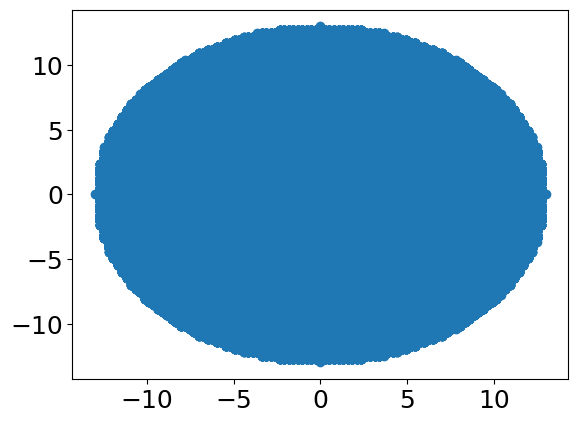

In [210]:
#Sphere
D = 26            # diameter of the sphere
spacing = D/100   # spacing between grid points
points = grid_points_in_sphere(D, spacing)

#Cube
#points = fill_cube_with_points(N=100000, edge_length=15)

ones = np.array([1]*len(points))
points = np.hstack((points, ones.reshape(-1,1)))
plt.scatter(points[:,0], points[:,2])
plt.show()

## Calculate the Scattering curve 
This next section reads the positions and orientations from the simulation frames of the .gsd file and calculates the scattering curve of the specified frame. 

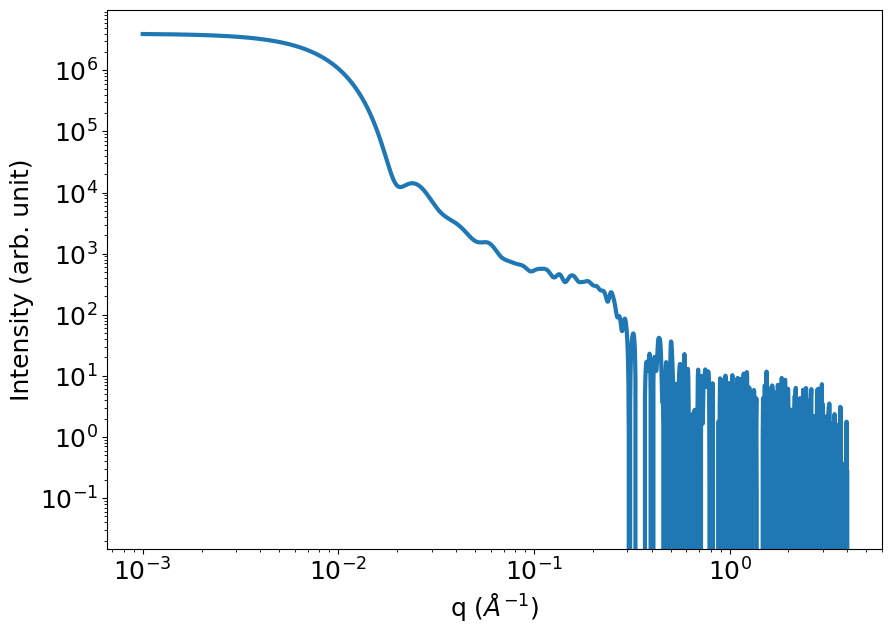

In [211]:

################################## INPUTS ##########################################################################################

        # Determines how many SAXS simulations occur per frame  
histogram_bins = 10000            # Number of bins in the pairwise distribution calculation 
q = np.geomspace(0.001, 4, 2000)  # SAXS q-range to be calculated
path = '../Data/HOOMD/core_shell_cube_assembly_0.1_edge_length/assembly_2/'  # Where to save the files and plot

####################################################################################################################################
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(10,7))

n_samples = 5000000
simulator = pairwise_method.scattering_simulator(n_samples)
simulator.sample_building_block(points)
simulator.sample_lattice_coordinates(lattice_coordinates)
simulator.calculate_structure_coordinates()
# I_q = simulator.simulate_multiple_scattering_curves_lattice_coords(points, lattice_coordinates[i], histogram_bins, q, save=False).numpy()
# I_q = np.mean(I_q, axis=1)
I_q = simulator.simulate_scattering_curve_fast_lattice(points, lattice_coordinates, histogram_bins, q, save=False).numpy()
plt.rcParams.update({'font.size': 18})        
ax.plot(q, I_q, linewidth = 3, label = '10m Sample Size')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=14)
data = np.hstack((q.reshape(-1,1), I_q.reshape(-1,1)))
np.save('../Data/Aggregates/scattering_curve_fractal_agg_26nm_particle_26.npy', data)   


## Simulation object

This section plots the simulation object of the last frame from the .gsd file and can be used as a way to check if the simulated object matches the expected one. The simulation object is made up of the randomly selected pariwise distances that were used to calculate the scattering curve. 

Text(0, 0.5, 'y - direction')

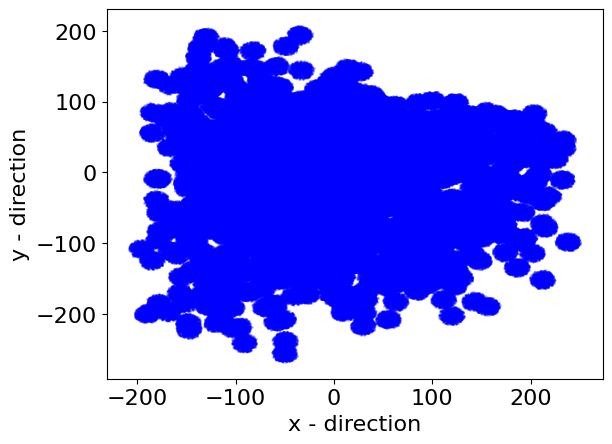

In [38]:
struc = simulator.structure_coordinates_1
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots()
ax.scatter(struc[:,0], struc[:,1], alpha = 0.25, s=1, color = 'blue')
ax.set_xlabel('x - direction')
ax.set_ylabel('y - direction')

the same plot in another perspective

Text(0, 0.5, 'z - direction')

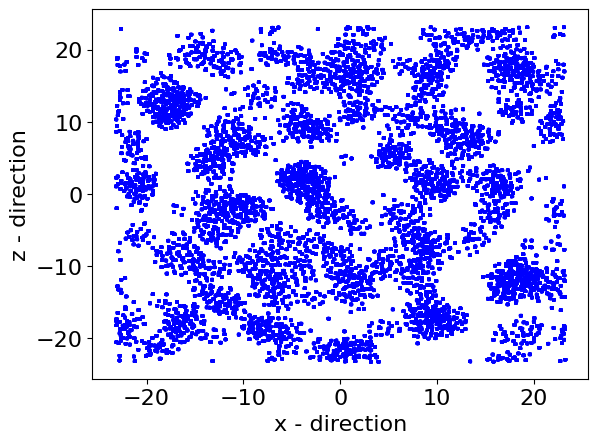

In [13]:
struc = simulator.structure_coordinates_1
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots()
ax.scatter(struc[:,0], struc[:,2], alpha = 0.25, s=1, color = 'blue')
ax.set_xlabel('x - direction')
ax.set_ylabel('z - direction')

## HOOMD Simulation Code 
This code was used to create the sphere assemblies. It will only work with HOOMD installed. 

In [117]:
data0.shape

(1740, 2)

In [212]:
data0 = np.load('../Data/Aggregates/scattering_curve_fractal_agg_26nm_particle_26.npy')[700:-400, :] 
#data10 = np.load('../Data/Aggregates/scattering_curve_fractal_agg_26nm_particle_10_spacing.npy')[800:-400, :] 
data10 = np.load('../Data/Aggregates/scattering_curve_fractal_agg_26nm_particle_26_8.npy' )[700:-400, :] 
data27 = np.load('../Data/Aggregates/scattering_curve_fractal_agg_26nm_particle_26_8_19.npy')[700:-400, :]  

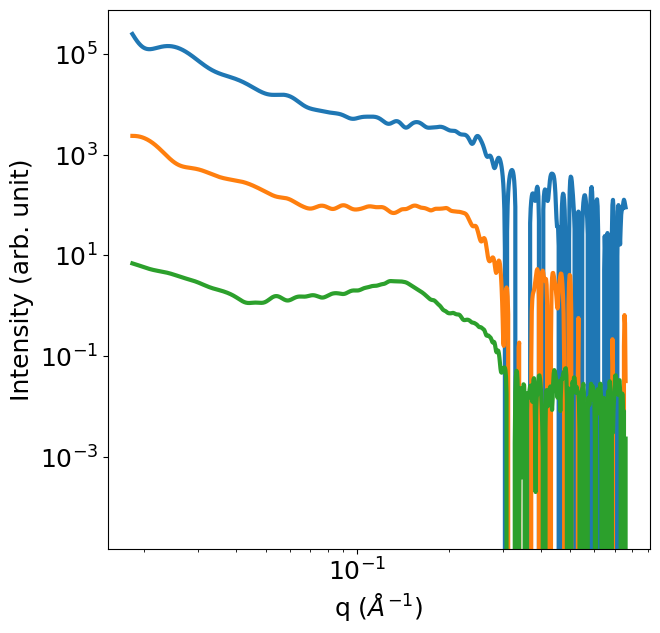

In [214]:
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(figsize=(7,7))      
ax.plot(data0[:,0], data0[:,1]*1e1, linewidth = 3, label = '')
ax.plot(data10[:,0], data10[:,1]*1e-1, linewidth = 3, label = '')
ax.plot(data27[:,0], data27[:,1]*1e-3, linewidth = 3, label = '')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Intensity (arb. unit)')
ax.set_xlabel('q ($\\AA^{-1}$)')
#plt.legend(fontsize=14)
plt.savefig('../Images/fractal_aggregates/all_curves.png', dpi=600, bbox_inches="tight")